## PANDAS — COMPLETE GUIDE

### 1. What is Pandas?

Pandas is a Python library used for:
- Data cleaning
- Data analysis
- Data manipulation
- Working with CSV, Excel, SQL files
- Handling tables (row/column data) like in Excel

Two main data structures:
- Series → 1D
- DataFrame → 2D table

### 2. Installing Pandas
> pip install pandas

### 3. Importing Pandas

In [1]:
import pandas as pd

### 4. Pandas Data Structures

Series (1D) has:
- values
- index

In [2]:
s = pd.Series([10, 20, 30])
s

0    10
1    20
2    30
dtype: int64

In [3]:
# DataFrame (2D)
df = pd.DataFrame({
    "name": ["A", "B"],
    "age": [20, 25]
})
df

,name,age
0,A,20
1,B,25


### 5. Reading and Writing Files

#### Read:
- df = pd.read_csv("file.csv")
- df = pd.read_excel("file.xlsx")
- df = pd.read_json("file.json")
- df = pd.read_sql(query, connection)

#### Write:
- df.to_csv("out.csv", index=False)
- df.to_excel("out.xlsx")
- df.to_json("out.json")

### 6. Basic DataFrame Operations

In [4]:
df.head()    # first 5 rows

,name,age
0,A,20
1,B,25


In [5]:
df.tail()    # last 5 rows

,name,age
0,A,20
1,B,25


In [6]:
df.info()    # summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    2 non-null      object
 1   age     2 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 164.0+ bytes


In [7]:
df.describe() # statistics

,age
count,2.000000
mean,22.500000
std,3.535534
min,20.000000
25%,21.250000
50%,22.500000
75%,23.750000
max,25.000000


In [8]:
df.shape     # rows, columns

(2, 2)

In [9]:
df.columns   # column names

Index(['name', 'age'], dtype='object')

In [10]:
df.index    # index numbers

RangeIndex(start=0, stop=2, step=1)

In [11]:
df.dtypes     # data types

name    object
age      int64
dtype: object

### 7. Selecting Data

In [12]:
# Column selection
df["age"]

0    20
1    25
Name: age, dtype: int64

In [13]:
df.age

0    20
1    25
Name: age, dtype: int64

In [14]:
# Multiple columns
df[["name", "age"]]

,name,age
0,A,20
1,B,25


In [15]:
# Row selection — loc (label-based)
df.loc[0]             # row by index label

name     A
age     20
Name: 0, dtype: object

In [16]:
df.loc[0:3]           # rows 0 to 3

,name,age
0,A,20
1,B,25


In [17]:
df.loc[:, "name"]     # all rows, column name

0    A
1    B
Name: name, dtype: object

In [18]:
# Row selection — iloc (position-based)
df.iloc[0]          # first row

name     A
age     20
Name: 0, dtype: object

In [19]:
df.iloc[0:3]        # first 3 rows

,name,age
0,A,20
1,B,25


In [20]:
df.iloc[:, 1]       # second column

0    20
1    25
Name: age, dtype: int64

### 8. Filtering Data (Boolean Indexing)

In [21]:
df = pd.DataFrame({
    "name": ["A", "B"],
    "age": [20, 25],
    "city": ["Delhi", "Mumbai"]
})
df

,name,age,city
0,A,20,Delhi
1,B,25,Mumbai


In [22]:
df[df["age"] > 20]

,name,age,city
1,B,25,Mumbai


In [23]:
df[(df.age > 15) & (df.city == "Delhi")]

,name,age,city
0,A,20,Delhi


In [24]:
# Using .query():
df.query("age > 15 and city == 'Delhi'")

,name,age,city
0,A,20,Delhi


### 9. Missing Values
- df.isnull()
- df.isnull().sum()
- df.dropna()
- df.fillna(0)
- df.fillna(df.mean())

### 10. Adding / Modifying Columns

In [25]:
df["new"] = df["age"] * 2
df

,name,age,city,new
0,A,20,Delhi,40
1,B,25,Mumbai,50


In [26]:
df["is_adult"] = df["age"] > 18
df

,name,age,city,new,is_adult
0,A,20,Delhi,40,True
1,B,25,Mumbai,50,True


In [27]:
df.rename(columns={"age": "Age"}, inplace=True)
df

,name,Age,city,new,is_adult
0,A,20,Delhi,40,True
1,B,25,Mumbai,50,True


### 11. Deleting Columns and Rows

In [28]:
df.drop("Age", axis=1)

,name,city,new,is_adult
0,A,Delhi,40,True
1,B,Mumbai,50,True


In [29]:
df.drop([0])   # delete row

,name,Age,city,new,is_adult
1,B,25,Mumbai,50,True


### 12. Sorting

In [30]:
df = pd.DataFrame({
    "name": ["A", "B"],
    "age": [20, 25],
    "city": ["Delhi", "Mumbai"],
    "salary": [20000, 15000]
})
df

,name,age,city,salary
0,A,20,Delhi,20000
1,B,25,Mumbai,15000


In [31]:
df.sort_values("age")

,name,age,city,salary
0,A,20,Delhi,20000
1,B,25,Mumbai,15000


In [32]:
df.sort_values(["age", "salary"], ascending=[False, True])

,name,age,city,salary
1,B,25,Mumbai,15000
0,A,20,Delhi,20000


### 13. Grouping (GroupBy)

In [33]:
df.groupby("city")["salary"].mean()

city
Delhi     20000.0
Mumbai    15000.0
Name: salary, dtype: float64

In [34]:
df.groupby("city").agg({"salary": "sum", "age": "mean"})

,salary,age
city,,
Delhi,20000,20.0
Mumbai,15000,25.0


### 14. Aggregation

In [35]:
df["age"].mean()

np.float64(22.5)

In [36]:
df["age"].sum()

np.int64(45)

In [37]:
df["age"].max()

25

In [38]:
df["age"].min()

20

In [39]:
df["age"].unique()

array([20, 25])

In [40]:
df["age"].value_counts()

age
20    1
25    1
Name: count, dtype: int64

### 15. Merging, Joining & Concatenating

#### Merge (like SQL join)

In [41]:
df1 = pd.DataFrame({
    "id": [1, 2, 3],
    "name": ["A", "B", "C"]
})
df1

,id,name
0,1,A
1,2,B
2,3,C


In [42]:
df2 = pd.DataFrame({
    "id": [1, 2, 4],
    "score": [90, 85, 70]
})
df2

,id,score
0,1,90
1,2,85
2,4,70


In [43]:
# Inner Join (default)
pd.merge(df1, df2, on="id")

,id,name,score
0,1,A,90
1,2,B,85


In [44]:
# Left Join
pd.merge(df1, df2, on="id", how="left")

,id,name,score
0,1,A,90.0
1,2,B,85.0
2,3,C,NaN


In [45]:
# Outer Join (Full Join)
pd.merge(df1, df2, on="id", how="outer")

,id,name,score
0,1,A,90.0
1,2,B,85.0
2,3,C,NaN
3,4,NaN,70.0


#### Concat (stacking)

In [46]:
pd.concat([df1, df2])          # vertical

,id,name,score
0,1,A,NaN
1,2,B,NaN
2,3,C,NaN
0,1,NaN,90.0
1,2,NaN,85.0
2,4,NaN,70.0


In [47]:
pd.concat([df1, df2], axis=1)  # horizontal

,id,name,id,score
0,1,A,1,90
1,2,B,2,85
2,3,C,4,70


### 16. Pivot Tables

In [48]:
data = {
    "city": ["Delhi", "Delhi", "Mumbai", "Mumbai", "Delhi", "Mumbai"],
    "month": ["Jan", "Feb", "Jan", "Feb", "Feb", "Jan"],
    "sales": [100, 150, 120, 130, 200, 180]
}

df = pd.DataFrame(data)
df

,city,month,sales
0,Delhi,Jan,100
1,Delhi,Feb,150
2,Mumbai,Jan,120
3,Mumbai,Feb,130
4,Delhi,Feb,200
5,Mumbai,Jan,180


In [49]:
df.pivot_table(values="sales", index="city", columns="month", aggfunc="sum")

month,Feb,Jan
city,,
Delhi,350,100
Mumbai,130,300


### 17. Apply Function

In [50]:
df = pd.DataFrame({
    "name": ["A", "B"],
    "age": [20, 25],
    "city": ["Delhi", "Mumbai"],
    "salary": [20000, 15000]
})
df

,name,age,city,salary
0,A,20,Delhi,20000
1,B,25,Mumbai,15000


In [51]:
# Apply custom functions to columns.
df["age2"] = df["age"].apply(lambda x: x * 2)
df

,name,age,city,salary,age2
0,A,20,Delhi,20000,40
1,B,25,Mumbai,15000,50


In [52]:
# Apply to rows:
result = df.apply(lambda row: row["age"] + row["salary"], axis=1)
result

0    20020
1    15025
dtype: int64

### 18. Handling Dates

In [53]:
data = {
    "event": ["Purchase", "Signup", "Login"],
    "date": ["2024-01-15", "2023-12-05", "2022-07-20"]
}

df = pd.DataFrame(data)
df

,event,date
0,Purchase,2024-01-15
1,Signup,2023-12-05
2,Login,2022-07-20


In [54]:
# Convert to datetime
df["date"] = pd.to_datetime(df["date"])
df

,event,date
0,Purchase,2024-01-15
1,Signup,2023-12-05
2,Login,2022-07-20


In [55]:
# Extract year and month
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df

,event,date,year,month
0,Purchase,2024-01-15,2024,1
1,Signup,2023-12-05,2023,12
2,Login,2022-07-20,2022,7


### 19. Advanced Indexing

In [56]:
df = pd.DataFrame({
    "id": [1, 2, 3],
    "name": ["A", "B", "C"],
    "score": [90, 85, 88]
})
df

,id,name,score
0,1,A,90
1,2,B,85
2,3,C,88


In [57]:
# Set index
df.set_index("id", inplace=True)
df

,name,score
id,,
1,A,90
2,B,85
3,C,88


In [58]:
# Reset index
df_reset = df.reset_index()
df_reset

,id,name,score
0,1,A,90
1,2,B,85
2,3,C,88


In [59]:
# Multi-Index Example
df = pd.DataFrame({
    "city": ["Delhi", "Delhi", "Mumbai", "Mumbai"],
    "year": [2020, 2021, 2020, 2021],
    "sales": [100, 120, 90, 110]
})
df

,city,year,sales
0,Delhi,2020,100
1,Delhi,2021,120
2,Mumbai,2020,90
3,Mumbai,2021,110


In [60]:
# Create Multi-Index
df_multi = df.set_index(["city", "year"])
df_multi

sales
city   year       
Delhi  2020    100
       2021    120
Mumbai 2020     90
       2021    110

### 20. Copy vs View

In [61]:
df = pd.DataFrame({
    "name": ["A", "B"],
    "age": [20, 25],
    "city": ["Delhi", "Mumbai"],
    "salary": [20000, 15000]
})
df

,name,age,city,salary
0,A,20,Delhi,20000
1,B,25,Mumbai,15000


In [62]:
x = df["age"]     # view (may affect original)
x

0    20
1    25
Name: age, dtype: int64

In [63]:
x = df["age"].copy()  # safe
x

0    20
1    25
Name: age, dtype: int64

### 21. Window Functions

In [64]:
df = pd.DataFrame({
    "city": ["Delhi", "Delhi", "Mumbai", "Mumbai"],
    "year": [2020, 2021, 2020, 2021],
    "sales": [100, 120, 90, 110]
})
df

,city,year,sales
0,Delhi,2020,100
1,Delhi,2021,120
2,Mumbai,2020,90
3,Mumbai,2021,110


In [65]:
# Rolling mean:
# Looks at a rolling window of 3 rows at a time.
df["roll"] = df["sales"].rolling(window=3).mean()
df

,city,year,sales,roll
0,Delhi,2020,100,NaN
1,Delhi,2021,120,NaN
2,Mumbai,2020,90,103.333333
3,Mumbai,2021,110,106.666667


In [66]:
# Expanding:
df["exp"] = df["sales"].expanding().sum()
df

,city,year,sales,roll,exp
0,Delhi,2020,100,NaN,100.0
1,Delhi,2021,120,NaN,220.0
2,Mumbai,2020,90,103.333333,310.0
3,Mumbai,2021,110,106.666667,420.0


### 22. Categorical Data

In [67]:
# This converts the city column from a normal string/object type
df["city"] = df["city"].astype("category")
df

,city,year,sales,roll,exp
0,Delhi,2020,100,NaN,100.0
1,Delhi,2021,120,NaN,220.0
2,Mumbai,2020,90,103.333333,310.0
3,Mumbai,2021,110,106.666667,420.0


### 23. String Functions

In [68]:
df = pd.DataFrame({
    "name": ["Aditya Chandel", "Riya Kapoor", "Sahil Singh"],
    "email": ["aditya@gmail.com", "riya@yahoo.com", "sahil@gmail.com"]
})
df

,name,email
0,Aditya Chandel,aditya@gmail.com
1,Riya Kapoor,riya@yahoo.com
2,Sahil Singh,sahil@gmail.com


In [69]:
df["name"].str.upper()

0    ADITYA CHANDEL
1       RIYA KAPOOR
2       SAHIL SINGH
Name: name, dtype: object

In [70]:
df["email"].str.contains("@gmail")

0     True
1    False
2     True
Name: email, dtype: bool

In [71]:
df["name"].str.split(" ", expand=True)

,0,1
0,Aditya,Chandel
1,Riya,Kapoor
2,Sahil,Singh


### 24. Data Cleaning Techniques
- Drop duplicates
- Replace values
- Fill NA
- Strip whitespace
- Type conversion

In [72]:
df = pd.DataFrame({
    "name": ["  Aditya  ", "Riya", "Sahil ", "Riya"],
    "gender": ["male", "female", "male", "female"],
    "age": ["20", "21", "20", "21"]
})
df

,name,gender,age
0,Aditya,male,20
1,Riya,female,21
2,Sahil,male,20
3,Riya,female,21


In [73]:
df.drop_duplicates()

,name,gender,age
0,Aditya,male,20
1,Riya,female,21
2,Sahil,male,20


In [74]:
df.replace({"male": "M", "female": "F"})

,name,gender,age
0,Aditya,M,20
1,Riya,F,21
2,Sahil,M,20
3,Riya,F,21


In [75]:
# to delete spaces
df["name"] = df["name"].str.strip()
df

,name,gender,age
0,Aditya,male,20
1,Riya,female,21
2,Sahil,male,20
3,Riya,female,21


In [76]:
# to convert string type to int tpye for age column
df["age"] = df["age"].astype("int")
df

,name,gender,age
0,Aditya,male,20
1,Riya,female,21
2,Sahil,male,20
3,Riya,female,21


### 25. Exporting Clean Data
- df.to_csv("clean.csv", index=False)
- df.to_excel("clean.xlsx")

### 26. Performance Optimization
- Use vectorized operations
- Avoid loops
- Use df.itertuples() (faster)
- Use categorical types
- Use df.memory_usage()
- Chunk loading:
   - pd.read_csv("big.csv", chunksize=50000)

### 27. Visualization

In [77]:
df = pd.DataFrame({
    "name": ["A", "B"],
    "age": [20, 25],
    "city": ["Delhi", "Mumbai"],
    "salary": [20000, 15000]
})
df

,name,age,city,salary
0,A,20,Delhi,20000
1,B,25,Mumbai,15000


<Axes: ylabel='Frequency'>

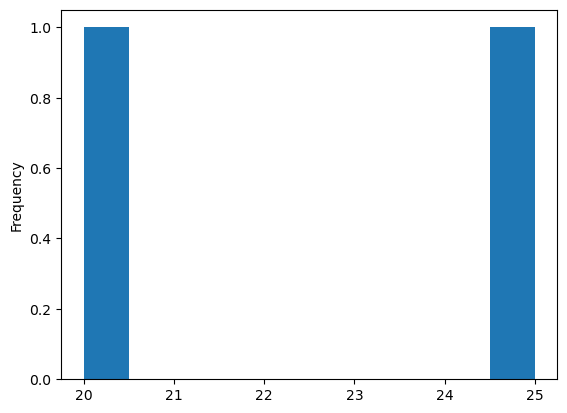

In [78]:
# Pandas uses matplotlib internally.
df["age"].plot(kind="hist")

<Axes: xlabel='age', ylabel='salary'>

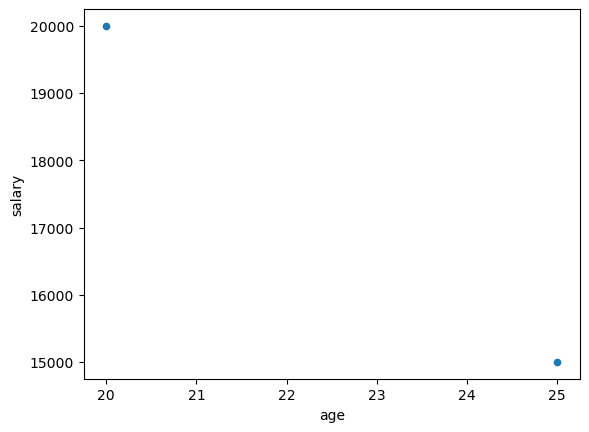

In [79]:
df.plot(x="age", y="salary", kind="scatter")

### 28. Multi-Level Operations

In [80]:
df.groupby(["city", "gender"])["salary"].mean()

city      20000.0
gender    15000.0
Name: salary, dtype: float64

### 29. Reshaping Data

In [81]:
# Melt:
pd.melt(df, id_vars=["city"])

,city,variable,value
0,Delhi,name,A
1,Mumbai,name,B
2,Delhi,age,20
3,Mumbai,age,25
4,Delhi,salary,20000
5,Mumbai,salary,15000


In [82]:
# Stack / Unstack:
df.stack()

0  name           A
   age           20
   city       Delhi
   salary     20000
1  name           B
   age           25
   city      Mumbai
   salary     15000
dtype: object

In [83]:
df.unstack()

name    0         A
        1         B
age     0        20
        1        25
city    0     Delhi
        1    Mumbai
salary  0     20000
        1     15000
dtype: object

### 30. Advanced Pandas Topics

#### 1. `.pipe()` — Clean Pipelines
Helps apply multiple functions in a readable way.

In [84]:
def add_column(df):
    df["total"] = df["a"] + df["b"]
    return df

def double_total(df):
    df["total"] = df["total"] * 2
    return df

df = pd.DataFrame({"a": [1,2], "b": [3,4]})
df

,a,b
0,1,3
1,2,4


In [85]:
df2 = (df
       .pipe(add_column)
       .pipe(double_total))

df2

,a,b,total
0,1,3,8
1,2,4,12


#### 2. `.eval()` — Faster Calculations
`eval()` computes expression faster than normal Python.

In [86]:
df = pd.DataFrame({"a": [10,20], "b": [1,2]})
df

,a,b
0,10,1
1,20,2


In [87]:
df["result"] = df.eval("a * b + 5")
df

,a,b,result
0,10,1,15
1,20,2,45


#### 3. `.assign()` — Create Multiple Columns

In [88]:
df = pd.DataFrame({"a": [1,2,3]})
df

,a
0,1
1,2
2,3


In [89]:
df2 = df.assign(
    b = df["a"] * 10,
    c = lambda d: d["b"] + 5
)
df2

,a,b,c
0,1,10,15
1,2,20,25
2,3,30,35


#### 4. `.merge_asof()` — Time-Series Merge
Like SQL join but for nearest timestamp.

In [90]:
df1 = pd.DataFrame({"time": [1, 5, 10], "value": [100, 200, 300]})
df1

,time,value
0,1,100
1,5,200
2,10,300


In [91]:
df2 = pd.DataFrame({"time": [2, 6, 12], "note": ["A", "B", "C"]})
df2

,time,note
0,2,A
1,6,B
2,12,C


In [92]:
# Matches each row with the closest earlier time.
merged = pd.merge_asof(df2, df1, on="time")
merged

,time,note,value
0,2,A,100
1,6,B,200
2,12,C,300


#### 5. `.explode()` — Split list-like columns
Turns lists into multiple rows.

In [93]:
df = pd.DataFrame({
    "name": ["A", "B"],
    "hobbies": [["cricket", "music"], ["reading"]]
})

df.explode("hobbies")

,name,hobbies
0,A,cricket
0,A,music
1,B,reading


#### 6. `.sample()` — Random Rows
Great for training/test splits.

In [94]:
df = pd.DataFrame({"a": range(10)})
df

,a
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7
8,8
9,9


In [95]:
df.sample(3) # pick 3 random rows

,a
4,4
3,3
0,0


In [96]:
df.sample(frac=0.5)  # pick 50% rows

,a
3,3
9,9
1,1
6,6
4,4


#### 7. `.nlargest()` — Top N Rows
Returns top 2 based on score.

In [97]:
df = pd.DataFrame({
    "name": ["A", "B", "C", "D"],
    "score": [50, 90, 70, 85]
})
df

,name,score
0,A,50
1,B,90
2,C,70
3,D,85


In [99]:
df.nlargest(2, "score")

,name,score
1,B,90
3,D,85
